# End-to-End Forecasting

This project applies several forecasting approaches to a simulated company financial dataset. Seasonal naive forecasting is used as a simple benchmark. Exponential smoothing, SARIMA, and SARIMAX are included because they are standard time series models for trend, seasonality, and autocorrelation. SARIMAX extends SARIMA by allowing external macroeconomic regressors. Prophet is included because it provides an interpretable additive forecasting framework for trend and seasonality and can incorporate additional regressors when future regressor values are available.

The target variable is monthly revenue. The forecasting features include time trend, calendar seasonality, lagged revenue, rolling average revenue, and macroeconomic indicators. Because this is time-series data, all lagged and rolling features are created using only past information. This avoids data leakage because the model never uses future revenue values to predict earlier months.

The forecasting objective is to predict monthly revenue levels, not differenced revenue. Although the revenue series may be non-stationary, machine learning models can still use lagged values, rolling averages, trend, and seasonal features to forecast revenue levels directly. Stationarity is more important for traditional ARIMA-style models than for tree-based machine learning models.

The final model is selected based on out-of-sample performance over the final 12 months using MAE, RMSE, MAPE, and R-squared. Because the dataset contains monthly financial data, the most important metric for business interpretation is MAPE, since it expresses forecast error as a percentage of revenue.


### Import Required Libraries

In [62]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import logging
import warnings

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

### Load Data

In [63]:
financials = pd.read_csv("data/monthly_financial_statements.csv")
macro = pd.read_csv("data/macro_indicators_monthly.csv")

financials["month"] = pd.to_datetime(financials["month"])
macro["month"] = pd.to_datetime(macro["month"])

financials.head()

,month,revenue,cogs,gross_profit,units,active_customers,return_rate,avg_days_to_collect,sales_marketing_expense,r_and_d_expense,g_and_a_expense,total_opex,ebitda,depreciation_amortization,operating_income,interest_expense,tax_expense,net_income,accounts_receivable,inventory,accounts_payable,capex,free_cash_flow,gross_margin,ebitda_margin,net_margin
0,2020-01-01,"7,876,820.54","3,853,402.07","4,023,418.54",6599,1691,0.05,50.45,"1,185,084.94","633,567.35","956,421.25","2,775,073.54","1,248,345.00","192,734.55","1,055,610.45","88,969.38","170,190.05","796,451.02","13,245,047.65","2,712,945.98","1,794,554.01","365,914.29","623,271.28",0.51,0.16,0.10
1,2020-02-01,"8,249,437.24","4,057,691.40","4,191,745.55",6376,1611,0.04,49.75,"1,256,457.88","771,306.84","884,015.96","2,911,780.68","1,279,964.87","298,538.90","981,425.97","116,661.57","143,872.99","720,891.41","13,681,145.42","2,802,054.43","2,300,415.33","519,026.87","481,058.54",0.51,0.16,0.09
2,2020-03-01,"8,537,230.51","4,224,043.52","4,313,186.96",6555,1673,0.05,50.45,"1,576,113.32","985,662.71","1,164,898.99","3,726,675.02","586,511.94","247,757.66","338,754.28","99,270.72","44,337.33","195,146.23","14,356,658.80","2,880,638.48","1,614,668.60","322,269.99","-1,319,210.26",0.51,0.07,0.02
3,2020-04-01,"8,159,591.71","3,959,527.24","4,200,064.61",6315,1622,0.04,50.09,"1,420,251.51","721,040.54","1,094,596.09","3,235,888.14","964,176.47","262,129.79","702,046.68","50,312.20","149,230.13","502,504.35","13,623,132.78","2,686,172.26","1,860,299.39","158,456.15","1,779,801.02",0.51,0.12,0.06
4,2020-05-01,"8,828,964.24","4,219,678.52","4,609,285.86",6714,1649,0.04,49.90,"1,456,139.49","923,516.63","1,077,155.15","3,456,811.27","1,152,474.59","153,441.36","999,033.23","63,455.30","208,817.83","726,760.10","14,685,194.07","2,623,922.59","1,743,433.26","460,418.39","-696,894.68",0.52,0.13,0.08


### Create Forecasting Dataset

In [64]:
forecast_df = (
    financials[["month", "revenue"]]
    .merge(macro, on="month", how="left")
    .sort_values("month")
    .reset_index(drop=True)
)

forecast_df["month"] = pd.to_datetime(forecast_df["month"])

# Ensure monthly frequency
forecast_df = (
    forecast_df
    .set_index("month")
    .asfreq("MS")
    .reset_index()
)

forecast_df["time_index"] = np.arange(len(forecast_df))
forecast_df["month_num"] = forecast_df["month"].dt.month
forecast_df["year"] = forecast_df["month"].dt.year

forecast_df.head()

,month,revenue,interest_rate,inflation_rate,unemployment_rate,business_confidence_index,market_index,exchange_rate_index,time_index,month_num,year
0,2020-01-01,"7,876,820.54",1.11,2.73,6.17,100.82,"1,005.02",100.51,0,1,2020
1,2020-02-01,"8,249,437.24",1.36,2.55,6.03,99.71,987.88,101.18,1,2,2020
2,2020-03-01,"8,537,230.51",1.23,2.96,6.21,103.86,999.85,101.53,2,3,2020
3,2020-04-01,"8,159,591.71",1.60,2.97,6.25,102.97,999.79,102.05,3,4,2020
4,2020-05-01,"8,828,964.24",1.71,2.34,6.20,105.31,"1,036.29",102.57,4,5,2020


### A Quick Data Check

In [65]:
print("Shape:", forecast_df.shape)
print("\nMissing values:")
print(forecast_df.isna().sum())

print("\nDate range:")
print(forecast_df["month"].min(), "to", forecast_df["month"].max())

print("\nRevenue summary:")
display(forecast_df["revenue"].describe())

Shape: (72, 11)

Missing values:
month                        0
revenue                      0
interest_rate                0
inflation_rate               0
unemployment_rate            0
business_confidence_index    0
market_index                 0
exchange_rate_index          0
time_index                   0
month_num                    0
year                         0
dtype: int64

Date range:
2020-01-01 00:00:00 to 2025-12-01 00:00:00

Revenue summary:


count           72.00
mean     8,897,114.85
std      1,029,992.90
min      6,976,526.48
25%      8,064,140.04
50%      8,854,613.16
75%      9,559,004.26
max     11,339,603.20
Name: revenue, dtype: float64

### Visualization

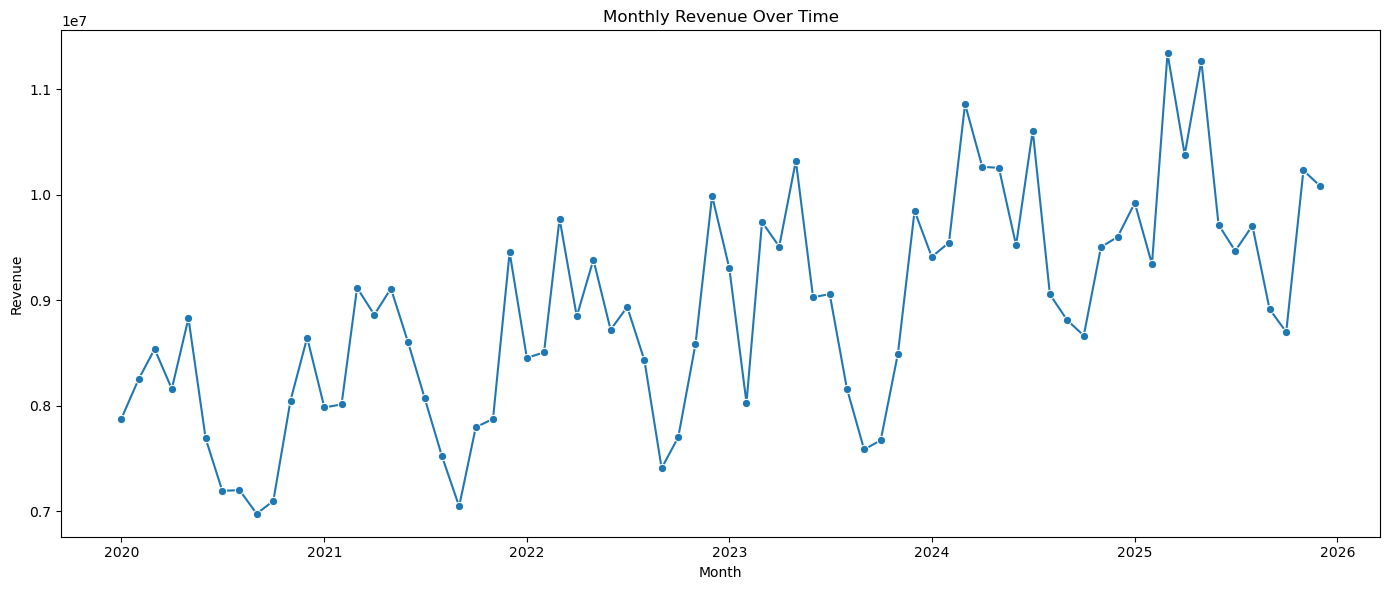

In [66]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=forecast_df,
    x="month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("figures/monthly_revenue_trend.png", dpi=300)
plt.show()

In [67]:
forecast_df = (
    financials[["month", "revenue"]]
    .merge(macro, on="month", how="left")
    .sort_values("month")
    .reset_index(drop=True)
)

forecast_df["month"] = pd.to_datetime(forecast_df["month"])

# Ensure monthly frequency
forecast_df = (
    forecast_df
    .set_index("month")
    .asfreq("MS")
    .reset_index()
)

forecast_df["time_index"] = np.arange(len(forecast_df))
forecast_df["month_num"] = forecast_df["month"].dt.month
forecast_df["year"] = forecast_df["month"].dt.year

forecast_df.head()

,month,revenue,interest_rate,inflation_rate,unemployment_rate,business_confidence_index,market_index,exchange_rate_index,time_index,month_num,year
0,2020-01-01,"7,876,820.54",1.11,2.73,6.17,100.82,"1,005.02",100.51,0,1,2020
1,2020-02-01,"8,249,437.24",1.36,2.55,6.03,99.71,987.88,101.18,1,2,2020
2,2020-03-01,"8,537,230.51",1.23,2.96,6.21,103.86,999.85,101.53,2,3,2020
3,2020-04-01,"8,159,591.71",1.60,2.97,6.25,102.97,999.79,102.05,3,4,2020
4,2020-05-01,"8,828,964.24",1.71,2.34,6.20,105.31,"1,036.29",102.57,4,5,2020


### Time Series Decomposition

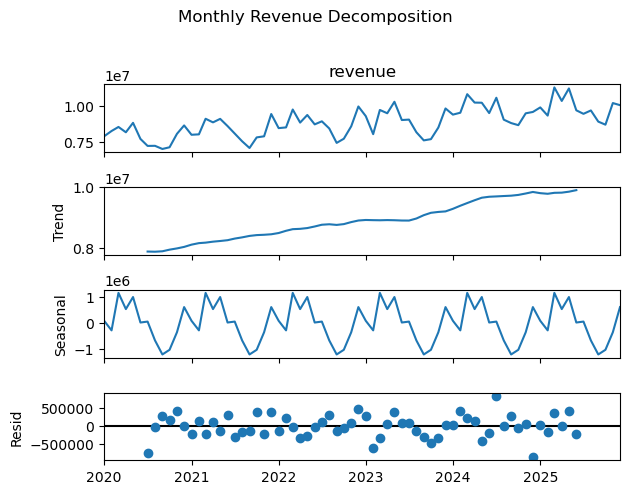

In [68]:
revenue_ts = forecast_df.set_index("month")["revenue"].asfreq("MS")

decomposition = seasonal_decompose(
    revenue_ts,
    model="additive",
    period=12
)

decomposition.plot()
plt.suptitle("Monthly Revenue Decomposition", y=1.02)
plt.tight_layout()
plt.savefig("figures/monthly_revenue_decomposition.png", dpi=300)
plt.show()

### Stationarity Check

In [69]:
def check_stationarity(series, name="Series"):
    result = adfuller(series.dropna())
    
    print(f"Stationarity Test for {name}")
    print("-" * 45)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    if result[1] <= 0.05:
        print("Conclusion: Stationary. Reject the null hypothesis of a unit root.")
    else:
        print("Conclusion: Non-stationary. Fail to reject the null hypothesis of a unit root.")

check_stationarity(forecast_df["revenue"], "Revenue")

forecast_df["revenue_diff"] = forecast_df["revenue"].diff()
check_stationarity(forecast_df["revenue_diff"], "Differenced Revenue")

Stationarity Test for Revenue
---------------------------------------------
ADF Statistic: -0.1986
p-value: 0.9387
Conclusion: Non-stationary. Fail to reject the null hypothesis of a unit root.
Stationarity Test for Differenced Revenue
---------------------------------------------
ADF Statistic: -10.5484
p-value: 0.0000
Conclusion: Stationary. Reject the null hypothesis of a unit root.


### Time-Based Train-Test Split

In [70]:
test_months = 12

train_ts = forecast_df.iloc[:-test_months].copy()
test_ts = forecast_df.iloc[-test_months:].copy()

y_train = train_ts["revenue"]
y_test = test_ts["revenue"]

print("Training period:", train_ts["month"].min(), "to", train_ts["month"].max())
print("Testing period:", test_ts["month"].min(), "to", test_ts["month"].max())
print("Train rows:", len(train_ts))
print("Test rows:", len(test_ts))

Training period: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
Testing period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Train rows: 60
Test rows: 12


### Evaluation Functions

In [71]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return np.mean(np.abs((y_true - y_pred) / y_true))

def evaluate_forecast(model_name, actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    return {
        "model": model_name,
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "mape": mape(actual, predicted),
        "r2": r2_score(actual, predicted)
    }

forecast_results = []
forecast_predictions = pd.DataFrame({
    "month": test_ts["month"].values,
    "actual_revenue": y_test.values
})

# Forecast revenue using time series structure

## Model 1: Seasonal Naive Baseline

In [72]:
seasonal_naive_preds = forecast_df["revenue"].shift(12).iloc[-test_months:].values

forecast_results.append(
    evaluate_forecast(
        "Seasonal Naive",
        y_test,
        seasonal_naive_preds
    )
)

forecast_predictions["Seasonal Naive"] = seasonal_naive_preds

## Model 2: Exponential Smoothing

In [73]:
ets_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True)

ets_preds = ets_model.forecast(test_months)

forecast_results.append(
    evaluate_forecast(
        "Exponential Smoothing",
        y_test,
        ets_preds
    )
)

forecast_predictions["Exponential Smoothing"] = ets_preds.values

## Model 3: SARIMA

In [74]:
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False,
    maxiter=1000,
    method="lbfgs"
)

print("Converged:", sarima_model.mle_retvals["converged"])

sarima_preds = sarima_model.forecast(steps=test_months)

forecast_results.append(
    evaluate_forecast(
        "SARIMA",
        y_test,
        sarima_preds
    )
)

forecast_predictions["SARIMA"] = sarima_preds.values

Converged: True


## Model 4: AUTO ARIMA

In [75]:

y_train_arima = pd.Series(y_train).astype(float)
y_test_arima = pd.Series(y_test).astype(float)

auto_arima_model = auto_arima(
    y_train_arima,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False
)

auto_arima_preds = auto_arima_model.predict(n_periods=test_months)

# Store results
forecast_results.append(
    evaluate_forecast(
        "Auto ARIMA",
        y_test_arima,
        auto_arima_preds
    )
)

forecast_predictions["Auto ARIMA"] = auto_arima_preds

print(auto_arima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -881.969
Date:                            Tue, 12 May 2026   AIC                           1769.938
Time:                                    19:36:53   BIC                           1776.171
Sample:                                         0   HQIC                          1772.371
                                             - 60                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    2.92e+04   1.14e+05      0.256      0.798   -1.95e+05    2.53e+05
ar.S.L12       0.1793      0.039   

# Forecast revenue using time series structure plus macro regressors

### Define Exogenous variables

In [76]:
exog_cols = [
    "interest_rate",
    "inflation_rate",
    "unemployment_rate",
    "business_confidence_index",
    "market_index",
    "exchange_rate_index"
]

# Make sure the columns exist
missing_cols = [col for col in exog_cols if col not in train_ts.columns]

if missing_cols:
    print("These exogenous columns are missing:", missing_cols)
else:
    print("All exogenous columns are available.")

# Prepare train and test exogenous variables
X_train_exog = (
    train_ts[exog_cols]
    .astype(float)
    .ffill()
    .bfill()
)

X_test_exog = (
    test_ts[exog_cols]
    .astype(float)
    .ffill()
    .bfill()
)

print("X_train_exog shape:", X_train_exog.shape)
print("X_test_exog shape:", X_test_exog.shape)

All exogenous columns are available.
X_train_exog shape: (60, 6)
X_test_exog shape: (12, 6)


## Model 5: AUTO ARIMAX with Macro Regressors

In [77]:
auto_arimax_model = auto_arima(
    y_train,
    X=X_train_exog,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False)
    
auto_arimax_preds = auto_arimax_model.predict(
    n_periods=test_months,
    X=X_test_exog)
    
forecast_results.append(evaluate_forecast(
    "Auto ARIMAX",
    y_test,
    auto_arimax_preds))
    
forecast_predictions["Auto ARIMAX"] = auto_arimax_preds
    
print(auto_arimax_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -879.890
Date:                            Tue, 12 May 2026   AIC                           1777.780
Time:                                    19:36:54   BIC                           1796.629
Sample:                                         0   HQIC                          1785.153
                                             - 60                                         
Covariance Type:                              opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
interest_rate              1.953e+05   5.88e+05      0.332      0.740   -9.56e+05   

## Model 6: SARIMAX with Exogenous predictors

In [78]:
exog_cols = [
    "interest_rate",
    "inflation_rate",
    "unemployment_rate",
    "business_confidence_index",
    "market_index",
    "exchange_rate_index"
]

X_train_exog = train_ts[exog_cols]
X_test_exog = test_ts[exog_cols]

sarimax_model = SARIMAX(
    y_train,
    exog=X_train_exog,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_preds = sarimax_model.forecast(
    steps=test_months,
    exog=X_test_exog
)

forecast_results.append(
    evaluate_forecast(
        "SARIMAX",
        y_test,
        sarimax_preds
    )
)

forecast_predictions["SARIMAX"] = sarimax_preds.values

## Forecast revenue using trend and seasonality, optionally with macro regressors.

## Model 7: Prophet

In [79]:

prophet_train = train_ts[["month", "revenue"]].rename(
    columns={
        "month": "ds",
        "revenue": "y" })

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive")

prophet_model.fit(prophet_train)

prophet_future = test_ts[["month"]].rename(
    columns={"month": "ds"} )

prophet_forecast = prophet_model.predict(prophet_future)

prophet_preds = prophet_forecast["yhat"].values

forecast_results.append(
    evaluate_forecast(
        "Prophet",
        y_test,
        prophet_preds))

forecast_predictions["Prophet"] = prophet_preds

## Model 8: Prophet with Macro Regressors

In [80]:
prophet_exog_train = train_ts[["month", "revenue"] + exog_cols].rename(
    columns={
        "month": "ds",
        "revenue": "y"
    }
)

prophet_exog_test = test_ts[["month"] + exog_cols].rename(
    columns={"month": "ds"}
)

prophet_exog_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

for col in exog_cols:
    prophet_exog_model.add_regressor(col)

prophet_exog_model.fit(prophet_exog_train)

prophet_exog_forecast = prophet_exog_model.predict(prophet_exog_test)

prophet_exog_preds = prophet_exog_forecast["yhat"].values

forecast_results.append(
    evaluate_forecast(
        "Prophet with Regressors",
        y_test,
        prophet_exog_preds
    )
)

forecast_predictions["Prophet with Regressors"] = prophet_exog_preds

## Forecast monthly revenue levels using lagged revenue, rolling averages, trend, seasonality, and macro variables.

### Machine Learning Feature Engineering

In [81]:
ml_df = forecast_df.copy()

ml_df["revenue_lag_1"] = ml_df["revenue"].shift(1)
ml_df["revenue_lag_3"] = ml_df["revenue"].shift(3)
ml_df["revenue_lag_6"] = ml_df["revenue"].shift(6)
ml_df["revenue_lag_12"] = ml_df["revenue"].shift(12)

ml_df["revenue_roll_3"] = ml_df["revenue"].shift(1).rolling(3).mean()
ml_df["revenue_roll_6"] = ml_df["revenue"].shift(1).rolling(6).mean()
ml_df["revenue_roll_12"] = ml_df["revenue"].shift(1).rolling(12).mean()

ml_df["revenue_growth_lag_1"] = ml_df["revenue"].pct_change().shift(1)

ml_df = pd.get_dummies(
    ml_df,
    columns=["month_num"],
    drop_first=True
)

ml_df = ml_df.dropna().reset_index(drop=True)

ml_df.head()

,month,revenue,interest_rate,inflation_rate,unemployment_rate,business_confidence_index,market_index,exchange_rate_index,time_index,year,revenue_diff,revenue_lag_1,revenue_lag_3,revenue_lag_6,revenue_lag_12,revenue_roll_3,revenue_roll_6,revenue_roll_12,revenue_growth_lag_1,month_num_2,month_num_3,month_num_4,month_num_5,month_num_6,month_num_7,month_num_8,month_num_9,month_num_10,month_num_11,month_num_12
0,2021-01-01,"7,983,285.84",2.08,1.97,5.71,94.07,"1,083.47",99.09,12,2021,"-661,960.64","8,645,246.48","7,097,704.26","7,193,144.72","7,876,820.54","7,930,738.94","7,526,986.80","7,875,272.60",0.07,False,False,False,False,False,False,False,False,False,False,False
1,2021-02-01,"8,012,820.30",2.05,1.52,5.47,93.10,"1,081.12",99.05,13,2021,"29,534.46","7,983,285.84","8,049,266.07","7,200,032.79","8,249,437.24","8,225,932.80","7,658,676.99","7,884,144.70",-0.08,True,False,False,False,False,False,False,False,False,False,False
2,2021-03-01,"9,117,298.14",2.08,1.91,5.40,96.08,"1,101.05",97.84,14,2021,"1,104,477.84","8,012,820.30","8,645,246.48","6,976,526.48","8,537,230.51","8,213,784.21","7,794,141.57","7,864,426.63",0.00,False,True,False,False,False,False,False,False,False,False,False
3,2021-04-01,"8,862,282.72",2.16,1.66,5.23,96.72,"1,098.45",98.86,15,2021,"-255,015.42","9,117,298.14","7,983,285.84","7,097,704.26","8,159,591.71","8,371,134.76","8,150,936.85","7,912,765.60",0.14,False,False,True,False,False,False,False,False,False,False,False
4,2021-05-01,"9,110,576.23",2.02,1.93,5.11,98.05,"1,148.46",99.03,16,2021,"248,293.51","8,862,282.72","8,012,820.30","8,049,266.07","8,828,964.24","8,664,133.72","8,445,033.26","7,971,323.18",-0.03,False,False,False,True,False,False,False,False,False,False,False


### Machine Learning Train-Test Split

In [82]:
ml_train = ml_df.iloc[:-test_months].copy()
ml_test = ml_df.iloc[-test_months:].copy()

target = "revenue"

drop_cols = [
    "month",
    "revenue",
    "revenue_diff"
]

drop_cols = [col for col in drop_cols if col in ml_df.columns]

X_train_ml = ml_train.drop(columns=drop_cols)
y_train_ml = ml_train[target]

X_test_ml = ml_test.drop(columns=drop_cols)
y_test_ml = ml_test[target]

print("ML training period:", ml_train["month"].min(), "to", ml_train["month"].max())
print("ML testing period:", ml_test["month"].min(), "to", ml_test["month"].max())
print("X_train_ml shape:", X_train_ml.shape)
print("X_test_ml shape:", X_test_ml.shape)

ML training period: 2021-01-01 00:00:00 to 2024-12-01 00:00:00
ML testing period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
X_train_ml shape: (48, 27)
X_test_ml shape: (12, 27)


### Feature Scaling

In [83]:
scaler = MinMaxScaler()

X_train_ml_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_ml),
    columns=X_train_ml.columns,
    index=X_train_ml.index
)

X_test_ml_scaled = pd.DataFrame(
    scaler.transform(X_test_ml),
    columns=X_test_ml.columns,
    index=X_test_ml.index
)

## Model 9: Linear Regression

In [84]:
lr_model = LinearRegression()
lr_model.fit(X_train_ml_scaled, y_train_ml)

lr_preds = lr_model.predict(X_test_ml_scaled)

forecast_results.append(
    evaluate_forecast(
        "Linear Regression",
        y_test_ml,
        lr_preds
    )
)

forecast_predictions["Linear Regression"] = lr_preds

## Model 10: Random Forest

In [85]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_ml_scaled, y_train_ml)

rf_preds = rf_model.predict(X_test_ml_scaled)

forecast_results.append(
    evaluate_forecast(
        "Random Forest",
        y_test_ml,
        rf_preds
    )
)

forecast_predictions["Random Forest"] = rf_preds

## Model 11: XGBOOST

In [86]:
if xgboost_available:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42
    )
    
    xgb_model.fit(X_train_ml_scaled, y_train_ml)
    
    xgb_preds = xgb_model.predict(X_test_ml_scaled)
    
    forecast_results.append(
        evaluate_forecast(
            "XGBoost",
            y_test_ml,
            xgb_preds
        )
    )
    
    forecast_predictions["XGBoost"] = xgb_preds

## Model Comparison Table

In [87]:
model_comparison = (
    pd.DataFrame(forecast_results)
    .sort_values("mape")
    .reset_index(drop=True)
)

model_comparison.to_csv(
    "outputs/forecast_model_comparison.csv",
    index=False
)

model_comparison

,model,mae,rmse,mape,r2
0,Prophet,"338,856.89","384,047.75",0.03,0.76
1,Exponential Smoothing,"356,196.27","416,014.78",0.04,0.72
2,Prophet with Regressors,"406,938.51","480,692.98",0.04,0.62
3,SARIMA,"434,720.03","561,598.31",0.04,0.48
4,Random Forest,"467,435.64","635,145.96",0.05,0.34
5,Seasonal Naive,"471,614.38","585,242.80",0.05,0.44
6,XGBoost,"520,806.49","674,913.81",0.05,0.25
7,Auto ARIMA,"576,763.46","749,986.84",0.06,0.07
8,Auto ARIMAX,"694,234.49","847,842.61",0.07,-0.18
9,Linear Regression,"1,147,287.05","1,244,868.77",0.12,-1.55


## Plot Actual vs All Model Forecasts

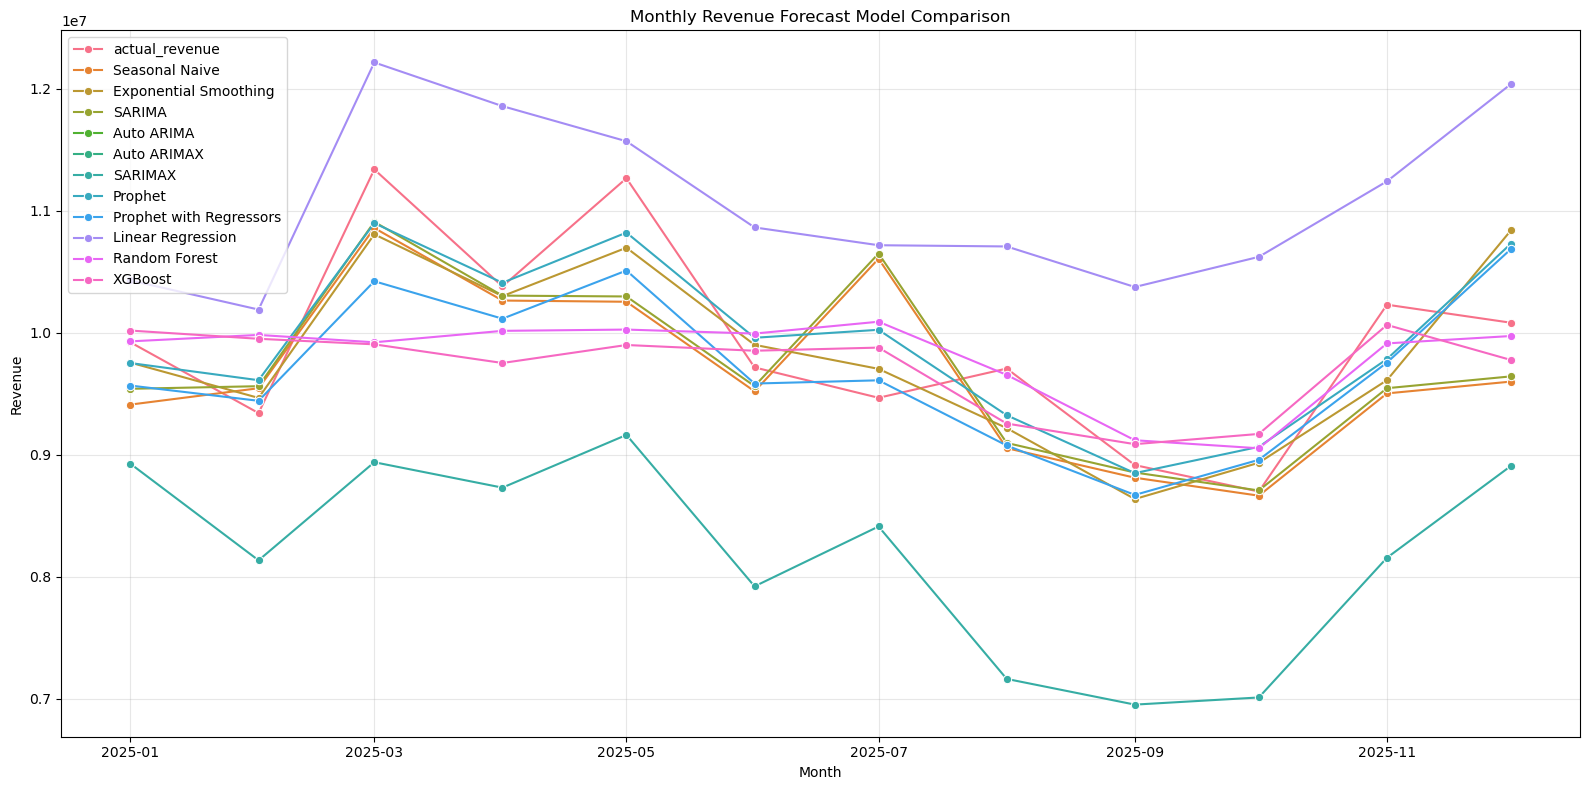

In [88]:
plot_df = forecast_predictions.melt(
    id_vars="month",
    var_name="model",
    value_name="revenue"
)

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=plot_df,
    x="month",
    y="revenue",
    hue="model",
    marker="o"
)

plt.title("Monthly Revenue Forecast Model Comparison")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/all_models_forecast_comparison.png", dpi=300)
plt.show()

## Plot Top 5 Models Only

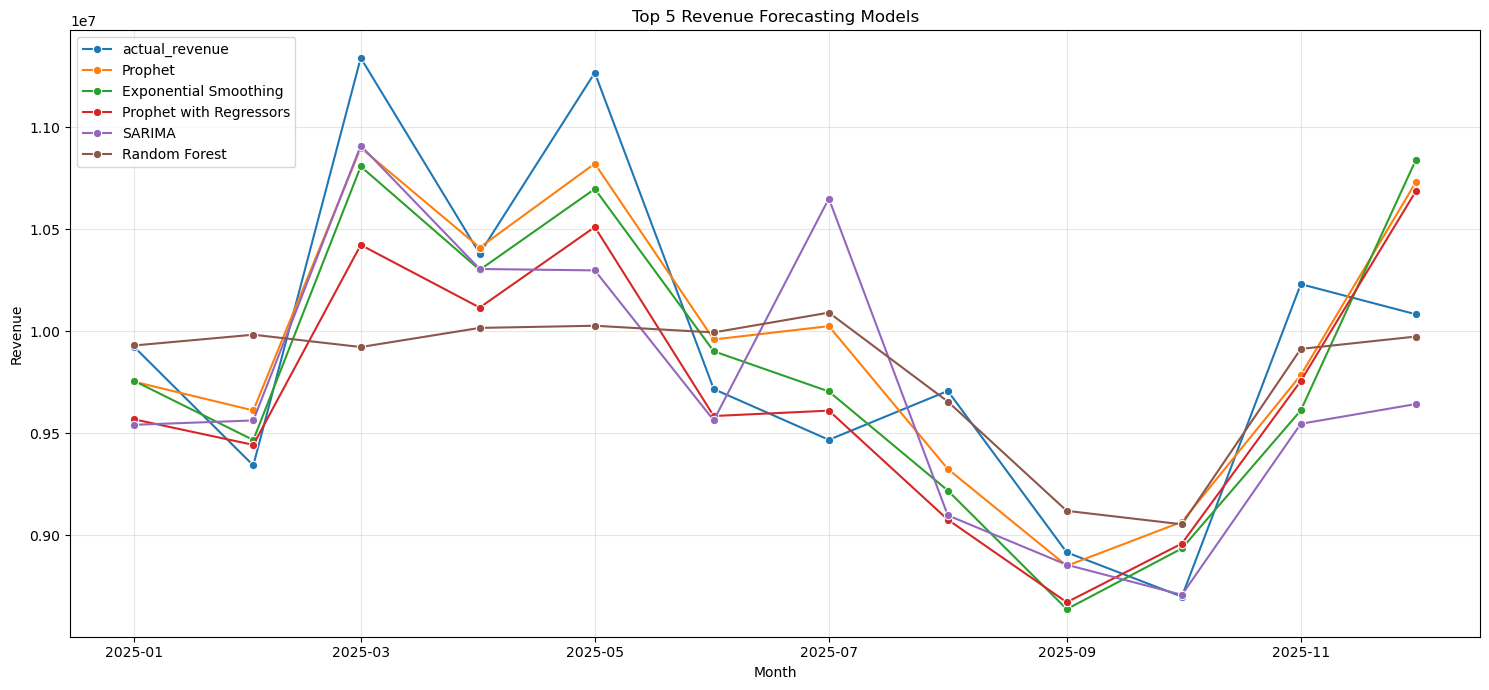

In [89]:
top_5_models = model_comparison["model"].head(5).tolist()

top_5_cols = ["month", "actual_revenue"] + top_5_models

top_5_plot_df = forecast_predictions[top_5_cols].melt(
    id_vars="month",
    var_name="model",
    value_name="revenue"
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=top_5_plot_df,
    x="month",
    y="revenue",
    hue="model",
    marker="o"
)

plt.title("Top 5 Revenue Forecasting Models")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/top_5_models_forecast_comparison.png", dpi=300)
plt.show()

In [90]:
## Select Best Model by MAPE
best_model_name = model_comparison.iloc[0]["model"]
best_mape = model_comparison.iloc[0]["mape"]

print(f"Best model based on MAPE: {best_model_name}")
print(f"MAPE: {best_mape:.2%}")

Best model based on MAPE: Prophet
MAPE: 3.40%


## Prophet Component Analysis

Unlike tree-based models such as Random Forest, Prophet does not produce feature importance scores. Instead, Prophet is interpreted through its forecast components, including trend and seasonality. When external regressors are included, their coefficients can also be examined. In this project, Prophet’s component plots are used to explain how trend and yearly seasonality contribute to the revenue forecast.

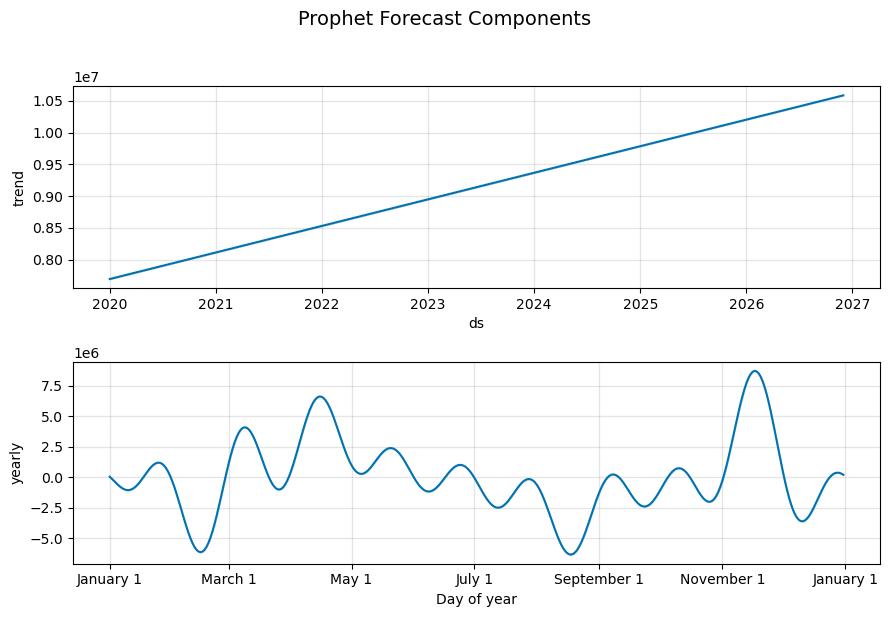

In [91]:
# Create full forecast including history
prophet_future_full = final_prophet_model.make_future_dataframe(
    periods=12,
    freq="MS",
    include_history=True
)

prophet_forecast_full = final_prophet_model.predict(prophet_future_full)

# Plot Prophet components
fig_components = final_prophet_model.plot_components(prophet_forecast_full)

plt.suptitle("Prophet Forecast Components", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/prophet_forecast_components.png", dpi=300, bbox_inches="tight")
plt.show()

## Prophet Trend and Seasonality Summary Table

In [92]:
component_cols = [
    col for col in ["trend", "yearly", "additive_terms"]
    if col in prophet_forecast_full.columns
]

prophet_component_summary = pd.DataFrame({
    "component": component_cols,
    "average_contribution": [
        prophet_forecast_full[col].mean()
        for col in component_cols
    ],
    "min_contribution": [
        prophet_forecast_full[col].min()
        for col in component_cols
    ],
    "max_contribution": [
        prophet_forecast_full[col].max()
        for col in component_cols
    ]
})

prophet_component_summary.to_csv(
    "outputs/prophet_component_summary.csv",
    index=False
)

prophet_component_summary

,component,average_contribution,min_contribution,max_contribution
0,trend,"9,142,430.68","7,696,177.01","10,588,956.04"
1,yearly,"-38,079.80","-1,418,932.79","1,280,151.38"
2,additive_terms,"-38,079.80","-1,418,932.79","1,280,151.38"


## Plot Prophet Component Contributions

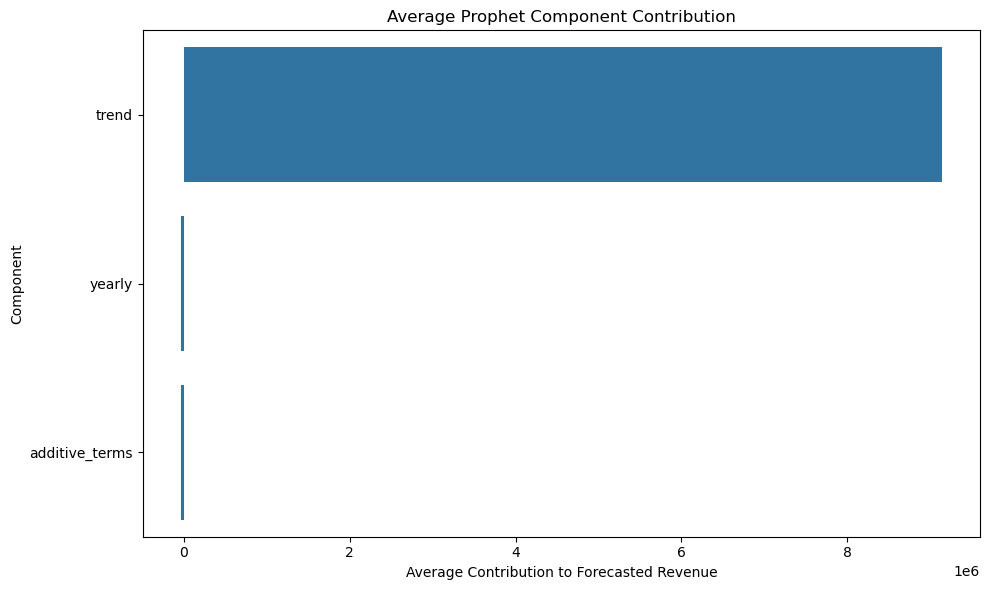

In [93]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=prophet_component_summary,
    x="average_contribution",
    y="component"
)

plt.title("Average Prophet Component Contribution")
plt.xlabel("Average Contribution to Forecasted Revenue")
plt.ylabel("Component")
plt.tight_layout()
plt.savefig("figures/prophet_component_contribution.png", dpi=300)
plt.show()

## Forward Forecast

Prophet produced the best out-of-sample forecasting performance based on MAPE. Therefore, the final 12-month forward forecast is generated using Prophet fitted on the full historical revenue series. The model is preferred because it captures trend and yearly seasonality while producing interpretable forecast intervals that are useful for financial planning and scenario analysis.

In [94]:
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# 1. Prepare full training data
prophet_full_data = (
    forecast_df[["month", "revenue"]]
    .rename(columns={"month": "ds", "revenue": "y"})
    .copy()
)

# 2. Fit Prophet on all available historical data
final_prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

final_prophet_model.fit(prophet_full_data)

# 3. Create future dates
future_periods = 12

future_dates = final_prophet_model.make_future_dataframe(
    periods=future_periods,
    freq="MS",
    include_history=False
)

# 4. Generate forecast
prophet_forecast = final_prophet_model.predict(future_dates)

# 5. Create clean forecast output
forecast_output = prophet_forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].rename(columns={
    "ds": "month",
    "yhat": "predicted_revenue",
    "yhat_lower": "lower_bound",
    "yhat_upper": "upper_bound"
})

forecast_output["predicted_revenue"] = forecast_output["predicted_revenue"].round(2)
forecast_output["lower_bound"] = forecast_output["lower_bound"].round(2)
forecast_output["upper_bound"] = forecast_output["upper_bound"].round(2)

forecast_output.to_csv(
    "outputs/future_revenue_forecast_12_months.csv",
    index=False
)

forecast_output

,month,predicted_revenue,lower_bound,upper_bound
0,2026-01-01,"10,273,821.58","9,877,114.92","10,671,397.13"
1,2026-02-01,"10,028,472.94","9,621,481.41","10,431,169.31"
2,2026-03-01,"11,218,671.66","10,791,610.88","11,614,757.14"
3,2026-04-01,"10,701,333.58","10,322,851.88","11,116,116.03"
4,2026-05-01,"11,385,638.44","10,974,609.44","11,780,569.20"
5,2026-06-01,"10,400,037.94","10,003,476.92","10,792,813.74"
6,2026-07-01,"10,408,892.86","10,030,284.89","10,809,295.98"
7,2026-08-01,"9,860,650.89","9,460,775.91","10,246,168.31"
8,2026-09-01,"9,170,466.54","8,776,329.44","9,554,436.51"
9,2026-10-01,"9,343,534.38","8,933,087.93","9,746,081.80"


## Plot Forward Forecast

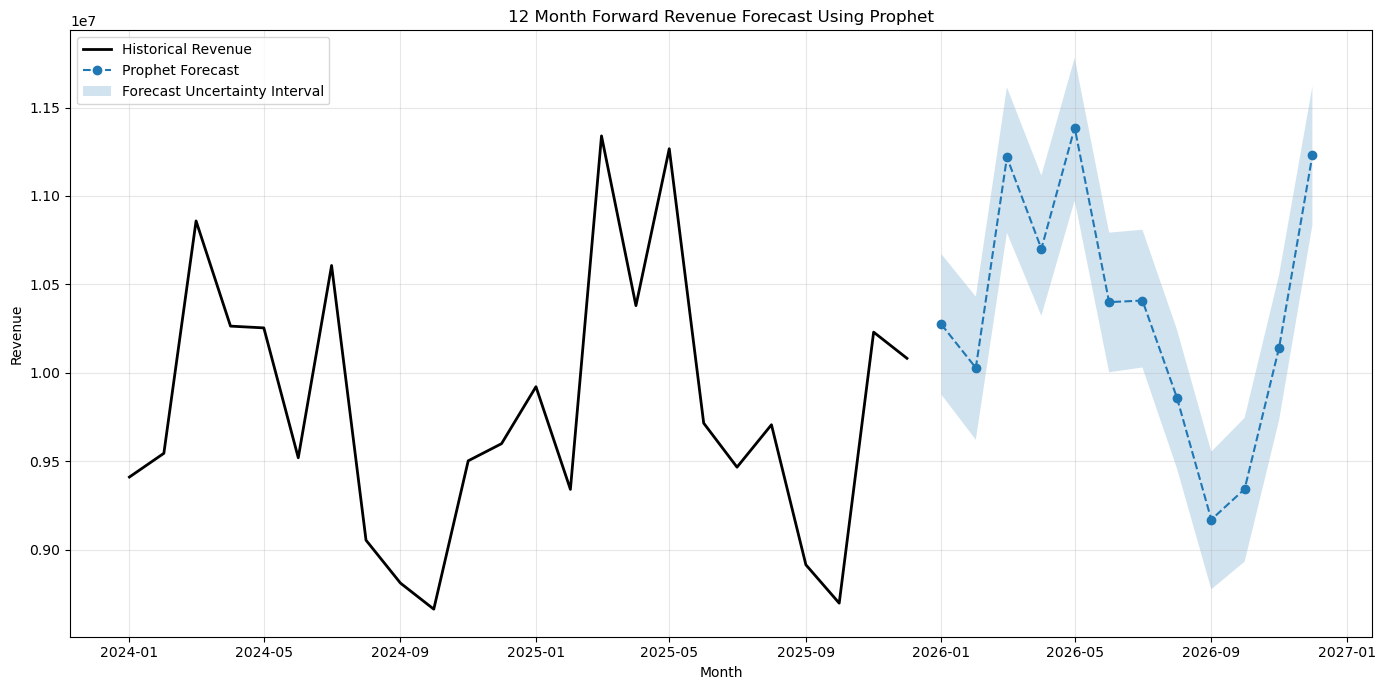

In [95]:
history = forecast_df[["month", "revenue"]].tail(24)

plt.figure(figsize=(14, 7))

plt.plot(
    history["month"],
    history["revenue"],
    label="Historical Revenue",
    color="black",
    linewidth=2
)

plt.plot(
    forecast_output["month"],
    forecast_output["predicted_revenue"],
    label="Prophet Forecast",
    linestyle="--",
    marker="o"
)

plt.fill_between(
    forecast_output["month"],
    forecast_output["lower_bound"],
    forecast_output["upper_bound"],
    alpha=0.20,
    label="Forecast Uncertainty Interval"
)

plt.title("12 Month Forward Revenue Forecast Using Prophet")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/prophet_future_revenue_forecast_12_months.png", dpi=300)
plt.show()

## Scenario Analysis

In [96]:
scenario_df = forecast_output[["month", "predicted_revenue"]].copy()

scenario_df["Downside Case"] = scenario_df["predicted_revenue"] * 0.90
scenario_df["Base Case"] = scenario_df["predicted_revenue"]
scenario_df["Upside Case"] = scenario_df["predicted_revenue"] * 1.10

scenario_df = scenario_df[
    ["month", "Downside Case", "Base Case", "Upside Case"]
]

scenario_df = scenario_df.round(2)

scenario_df.to_csv(
    "outputs/revenue_scenario_analysis.csv",
    index=False
)

scenario_df

,month,Downside Case,Base Case,Upside Case
0,2026-01-01,"9,246,439.42","10,273,821.58","11,301,203.74"
1,2026-02-01,"9,025,625.65","10,028,472.94","11,031,320.23"
2,2026-03-01,"10,096,804.49","11,218,671.66","12,340,538.83"
3,2026-04-01,"9,631,200.22","10,701,333.58","11,771,466.94"
4,2026-05-01,"10,247,074.60","11,385,638.44","12,524,202.28"
5,2026-06-01,"9,360,034.15","10,400,037.94","11,440,041.73"
6,2026-07-01,"9,368,003.57","10,408,892.86","11,449,782.15"
7,2026-08-01,"8,874,585.80","9,860,650.89","10,846,715.98"
8,2026-09-01,"8,253,419.89","9,170,466.54","10,087,513.19"
9,2026-10-01,"8,409,180.94","9,343,534.38","10,277,887.82"


## Plot Scenario Analysis

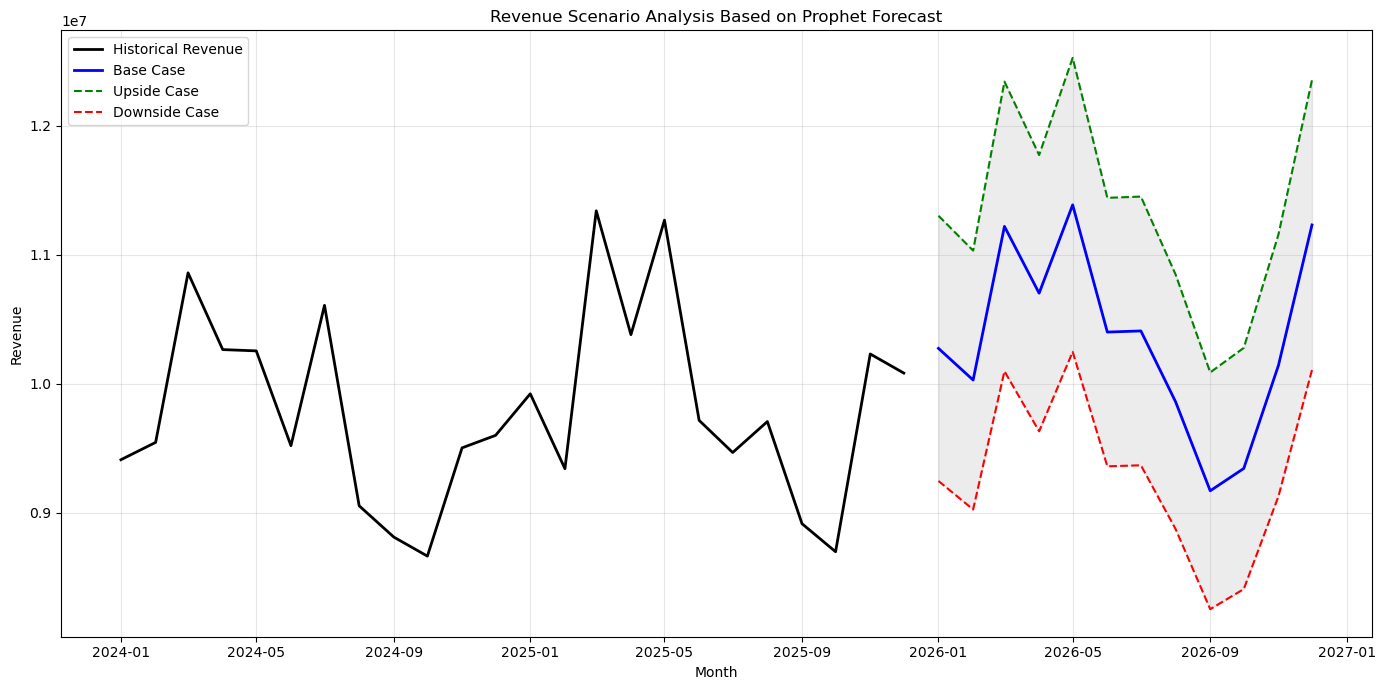

In [97]:
plt.figure(figsize=(14, 7))

plt.plot(
    history["month"],
    history["revenue"],
    color="black",
    label="Historical Revenue",
    linewidth=2
)

plt.plot(
    scenario_df["month"],
    scenario_df["Base Case"],
    color="blue",
    label="Base Case",
    linewidth=2
)

plt.plot(
    scenario_df["month"],
    scenario_df["Upside Case"],
    color="green",
    linestyle="--",
    label="Upside Case"
)

plt.plot(
    scenario_df["month"],
    scenario_df["Downside Case"],
    color="red",
    linestyle="--",
    label="Downside Case"
)

plt.fill_between(
    scenario_df["month"],
    scenario_df["Downside Case"],
    scenario_df["Upside Case"],
    color="gray",
    alpha=0.15
)

plt.title("Revenue Scenario Analysis Based on Prophet Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/prophet_revenue_scenario_analysis.png", dpi=300)
plt.show()

## Export Full Excel Report

In [98]:
with pd.ExcelWriter("outputs/prophet_revenue_forecasting_report.xlsx") as writer:
    forecast_df[["month", "revenue"]].to_excel(
        writer,
        sheet_name="Historical_Revenue",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )

    forecast_output.to_excel(
        writer,
        sheet_name="Prophet_Forecast",
        index=False
    )

    scenario_df.to_excel(
        writer,
        sheet_name="Scenario_Analysis",
        index=False
    )

print("Prophet revenue forecasting report exported successfully.")

Prophet revenue forecasting report exported successfully.
